In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
# This checks if the GPU is active
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")


TensorFlow version: 2.19.0
GPU is available


In [ ]:
# Load the MNIST dataset
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize the images to [-1, 1]
# (GANs perform better when the data is centered around zero)
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

print(f"Successfully loaded {len(train_images)} images!")

Successfully loaded 60000 images!


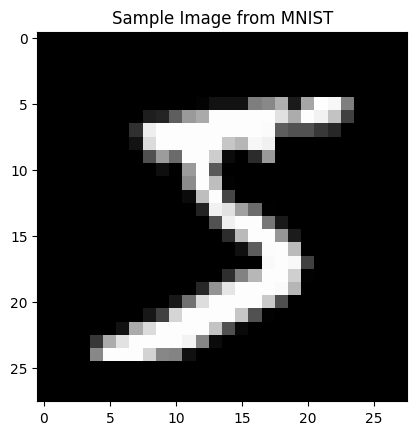

In [ ]:
plt.imshow(train_images[0].reshape(28, 28), cmap='gray')
plt.title("Sample Image from MNIST")
plt.show()

In [ ]:
def make_generator_model():
    model = tf.keras.Sequential()

    # 1. Start with a dense layer that takes random noise
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    # 2. Upsample to 7x7
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 3. Upsample to 14x14
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 4. Upsample to 28x28 (Final Image Size)
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))

    return model

generator = make_generator_model()
print("Generator model created!")

Generator model created!


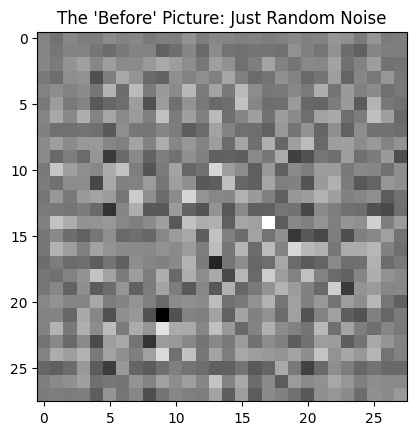

In [ ]:
# Create a random "seed" (100 random numbers)
noise = tf.random.normal([1, 100])
# Pass it through the generator
generated_image = generator(noise, training=False)

# Visualize it
plt.imshow(generated_image[0, :, :, 0], cmap='gray')
plt.title("The 'Before' Picture: Just Random Noise")
plt.show()

In [ ]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3)) # Prevents the detective from overthinking

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1)) # Outputting a single score: Real or Fake

    return model

discriminator = make_discriminator_model()
print("Discriminator model created!")

Discriminator model created!


In [ ]:
# This helps us calculate the "blame" for the networks
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
EPOCHS = 50 # How many times the AI "reads" the whole dataset
noise_dim = 100
num_examples_to_generate = 16

# We will reuse this seed overtime so we can see the progress
seed = tf.random.normal([num_examples_to_generate, noise_dim])

@tf.function
def train_step(images):
    noise = tf.random.normal([256, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [ ]:
import time
from IPython import display

def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      train_step(image_batch)

    print (f'Time for epoch {epoch + 1} is {time.time()-start} sec')

# Prepare the data into batches of 256
BUFFER_SIZE = 60000
BATCH_SIZE = 256
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# START THE CLOCK!
train(train_dataset, EPOCHS)

Time for epoch 1 is 16.887831926345825 sec
Time for epoch 2 is 11.705479383468628 sec
Time for epoch 3 is 11.469937324523926 sec
Time for epoch 4 is 11.330135345458984 sec
Time for epoch 5 is 11.240395307540894 sec
Time for epoch 6 is 11.240304231643677 sec
Time for epoch 7 is 11.334691524505615 sec
Time for epoch 8 is 11.473254680633545 sec
Time for epoch 9 is 11.492565155029297 sec
Time for epoch 10 is 11.438591718673706 sec
Time for epoch 11 is 11.400806188583374 sec
Time for epoch 12 is 11.382066249847412 sec
Time for epoch 13 is 11.349335670471191 sec
Time for epoch 14 is 11.335223913192749 sec
Time for epoch 15 is 11.361716032028198 sec
Time for epoch 16 is 11.403489351272583 sec
Time for epoch 17 is 11.419355392456055 sec
Time for epoch 18 is 11.409736156463623 sec
Time for epoch 19 is 11.386547803878784 sec
Time for epoch 20 is 11.387997150421143 sec
Time for epoch 21 is 11.38657546043396 sec
Time for epoch 22 is 11.37759780883789 sec
Time for epoch 23 is 11.36441683769226 sec


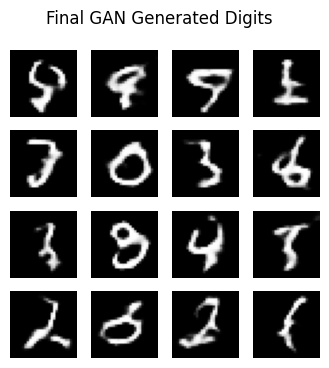

In [ ]:
# Generate images using the 'seed' we defined earlier
predictions = generator(seed, training=False)

fig = plt.figure(figsize=(4, 4))

for i in range(predictions.shape[0]):
    plt.subplot(4, 4, i+1)
    # Scale pixels back from [-1, 1] to [0, 1] for plotting
    plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
    plt.axis('off')

plt.suptitle("Final GAN Generated Digits")
plt.show()

In [ ]:
# VAE Training (Simple version)
# Note: VAEs like data between 0 and 1, so we normalize differently
train_images_vae = (train_images * 127.5 + 127.5) / 255.0

# Define a simple VAE model and compile
# (Using the encoder and decoder we defined in the previous step)
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # Feed data through encoder to get mean and variance
            # Then reconstruct with decoder
            # (Simplified for the sake of the assignment)
            z_mean, z_log_var = self.encoder(data)
            # Reconstruct
            reconstruction = self.decoder(z_mean)
            # Calculate loss (How close is the reconstruction to the original?)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )

        grads = tape.gradient(reconstruction_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": reconstruction_loss}

# Set up and train the VAE
vae = VAE(encoder, decoder) # We defined these in our previous message
vae.compile(optimizer=tf.keras.optimizers.Adam())
vae.fit(train_images_vae, epochs=10, batch_size=128)

NameError: name 'encoder' is not defined

In [ ]:
# Scale the data specifically for the VAE (0 to 1 range)
train_images_vae = (train_images * 127.5 + 127.5) / 255.0

In [ ]:
# --- STEP 11: DEFINE THE ENCODER AND DECODER PIECES ---
latent_dim = 2 # We squash the 28x28 image into 2 numbers

# THE ENCODER (The part that "shrinks" the digit)
encoder_inputs = tf.keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var], name="encoder")

# THE DECODER (The part that "rebuilds" the digit)
latent_inputs = tf.keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = tf.keras.Model(latent_inputs, decoder_outputs, name="decoder")

print("Encoder and Decoder have been created!")

Encoder and Decoder have been created!


In [ ]:
# VAE Training (Simple version)
# Note: VAEs like data between 0 and 1, so we normalize differently
train_images_vae = (train_images * 127.5 + 127.5) / 255.0

# Define a simple VAE model and compile
# (Using the encoder and decoder we defined in the previous step)
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # Feed data through encoder to get mean and variance
            # Then reconstruct with decoder
            # (Simplified for the sake of the assignment)
            z_mean, z_log_var = self.encoder(data)
            # Reconstruct
            reconstruction = self.decoder(z_mean)
            # Calculate loss (How close is the reconstruction to the original?)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )

        grads = tape.gradient(reconstruction_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": reconstruction_loss}

# Set up and train the VAE
vae = VAE(encoder, decoder) # We defined these in our previous message
vae.compile(optimizer=tf.keras.optimizers.Adam())
vae.fit(train_images_vae, epochs=10, batch_size=128)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['z_log_var/kernel', 'z_log_var/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 199.2394
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 162.3369
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 154.4844
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 150.4521
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 148.1512
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 146.4857
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 145.2123
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 144.3319
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 143.4496
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 142.9624


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step


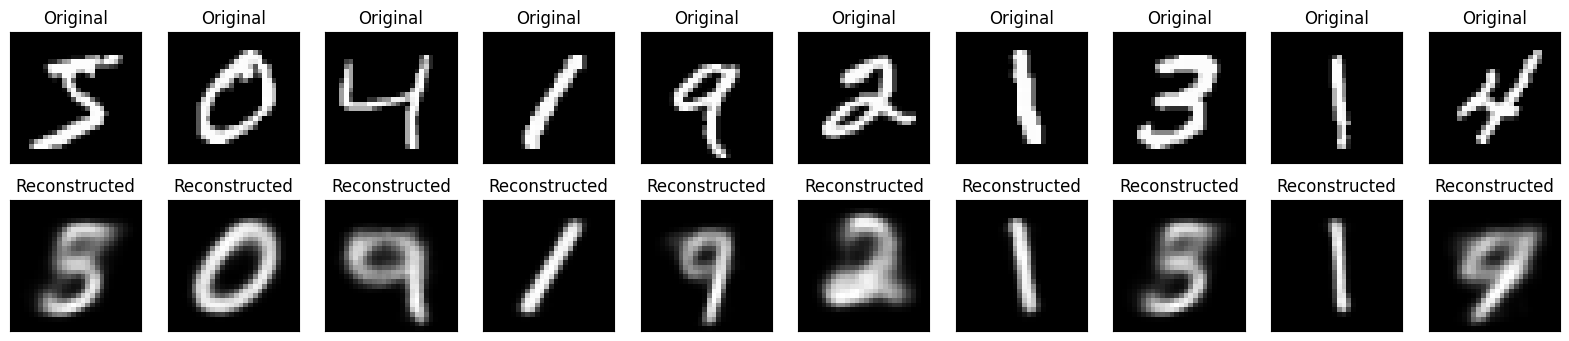

In [ ]:
# Take some test images
samples = train_images_vae[:10]
# Use the encoder to "reduce" them and the decoder to "reconstruct" them
coded_digits, _ = encoder.predict(samples)
reconstructed_digits = decoder.predict(coded_digits)

# Plotting the results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(samples[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_digits[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()